In [91]:
%pip install -q numpy pandas matplotlib tqdm easydict scipy shapely geopandas openpyxl scikit-learn descartes pyproj seaborn

Note: you may need to restart the kernel to use updated packages.


c:\Users\user\Desktop\대학원\기초연구실\ABM code\Outmigration_ABM\.venv\Scripts\python.exe: No module named pip


In [92]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 노트북 파일이 있는 폴더. 다른 곳에 데이터가 있다면 경로를 바꾸세요.
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR
GEOGRAPHY_DIR = PROJECT_DIR
CORE_FILE = PROJECT_DIR / 'outmigration_core.py'

required_paths = [
    CORE_FILE,
    DATA_DIR / 'ABM_city_info.xlsx',
    DATA_DIR / 'ABM_hospital_crd.xlsx',
    DATA_DIR / 'outside_polygon_mask.npy',
    GEOGRAPHY_DIR / 'Korea_shapefiles' / 'TL_SCCO_CTPRVN.shp',
]
missing = [str(path) for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError('다음 필수 파일을 찾을 수 없습니다:\n- ' + '\n- '.join(missing))

print('입력 파일 확인 완료')

입력 파일 확인 완료


In [93]:
import importlib.util

spec = importlib.util.spec_from_file_location('outmigration_core', CORE_FILE)
core = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = core
spec.loader.exec_module(core)

print('Core module loaded:', CORE_FILE)

Core module loaded: c:\Users\user\Desktop\대학원\기초연구실\ABM code\09171256_gym추가_son\outmigration_core.py


In [94]:
core.load_geographic_context(data_dir=DATA_DIR, geography_dir=GEOGRAPHY_DIR)
df_city_info, df_hospital_crd = core.load_simulation_inputs(data_dir=DATA_DIR)

display(df_city_info.head())
display(df_hospital_crd.head())
print(f'도시 수: {len(df_city_info):,}')
print(f'병원 좌표 행 수: {len(df_hospital_crd):,}')

c:\Users\user\Desktop\대학원\기초연구실\ABM code\Outmigration_ABM\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: One or several characters couldn't be converted correctly from euc-kr to UTF-8.  This warning will not be emitted anymore
  return ogr_read(
c:\Users\user\Desktop\대학원\기초연구실\ABM code\Outmigration_ABM\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: c:\Users\user\Desktop\대학원\기초연구실\ABM code\09171256_gym추가_son\Korea_shapefiles\TL_SCCO_CTPRVN.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


,SIDO_NM,POPULATION_REAL,POPULATION_1,NUM_HOSPITAL,REGION
0,서울,9384739,938,14,SM
1,부산,3287292,329,4,YN
2,대구,2369962,237,5,YN
3,인천,3006045,301,3,SM
4,광주,1415774,142,2,HN


,INST_NM,ADDRESS,NUM_BED,CRD_X,CRD_Y,SIDO_NM
11,충북대병원,"충청북도 청주시 서원구 1순환로 776-0, 충북대학교병원층 (개신동)",899,241219.392714,347064.680431,충북
12,단국대병원,충청남도 천안시 동남구 망향로 201 (안서동),1059,215074.474385,370829.421252,충남
33,전북대병원,전북특별자치도 전주시 덕진구 건지로 20 (금암동),1119,212643.409434,260771.391205,전북
14,원광대병원,전북특별자치도 익산시 무왕로 895 (신동),808,196147.777505,274170.300975,전북
43,화순전남병원,전라남도 화순군 화순읍 서양로 322,684,200196.505267,173373.290319,전남


도시 수: 17
병원 좌표 행 수: 47


In [104]:
parameter_set = core.make_default_parameter_set(df_city_info, df_hospital_crd)

# 실행 범위
parameter_set.max_dt = 100      
parameter_set.n_p = min(28, int(df_city_info[parameter_set.target_population_column].sum()))

np.random.seed(42)
core.random.seed(4242)

In [96]:
sim = core.Simulation(parameter_set)
sim.initialize()
sim.prepare_episode()

print(f'인구: {sim.num_population:,}, 병원: {sim.num_hospital:,}')
print('초기 OHQ 평균:', sim.df_Hospital_info['OQ_objective_quality'].mean())

for dt in range(parameter_set.max_dt):
    sim.advance_one_timestep(dt)
    print(f'dt={dt}: 신규 환자={sim.arr_hospital_volume[dt].sum()}, OHQ 평균={sim.achv_OHQ[dt].mean():.4f}')

인구: 5,129, 병원: 47
초기 OHQ 평균: 1.945767988595173
dt=0: 신규 환자=0, OHQ 평균=1.9458
dt=1: 신규 환자=0, OHQ 평균=1.9443
dt=2: 신규 환자=0, OHQ 평균=1.9387
dt=3: 신규 환자=0, OHQ 평균=1.9311
dt=4: 신규 환자=0, OHQ 평균=1.9246
dt=5: 신규 환자=0, OHQ 평균=1.9211
dt=6: 신규 환자=0, OHQ 평균=1.9289
dt=7: 신규 환자=0, OHQ 평균=1.9365
dt=8: 신규 환자=0, OHQ 평균=1.9420
dt=9: 신규 환자=0, OHQ 평균=1.9453
dt=10: 신규 환자=0, OHQ 평균=1.9469
dt=11: 신규 환자=0, OHQ 평균=1.9467
dt=12: 신규 환자=0, OHQ 평균=1.9451
dt=13: 신규 환자=0, OHQ 평균=1.9428
dt=14: 신규 환자=0, OHQ 평균=1.9397
dt=15: 신규 환자=0, OHQ 평균=1.9356
dt=16: 신규 환자=0, OHQ 평균=1.9307
dt=17: 신규 환자=0, OHQ 평균=1.9248
dt=18: 신규 환자=0, OHQ 평균=1.9189
dt=19: 신규 환자=0, OHQ 평균=1.9130
dt=20: 신규 환자=0, OHQ 평균=1.9068
dt=21: 신규 환자=0, OHQ 평균=1.9000
dt=22: 신규 환자=0, OHQ 평균=1.8925
dt=23: 신규 환자=0, OHQ 평균=1.8830
dt=24: 신규 환자=0, OHQ 평균=1.8719
dt=25: 신규 환자=0, OHQ 평균=1.8599
dt=26: 신규 환자=0, OHQ 평균=1.8471
dt=27: 신규 환자=0, OHQ 평균=1.8339
dt=28: 신규 환자=0, OHQ 평균=1.8218
dt=29: 신규 환자=0, OHQ 평균=1.8097
dt=30: 신규 환자=0, OHQ 평균=1.7968
dt=31: 신규 환자=0, OHQ 평균=1.7834
dt=

,hospital,total_new_patients,initial_OHQ,final_OHQ
0,강북삼성병원,0,2.186164,1.040601
1,서울대병원,0,2.186164,1.034825
2,이화여자대목동병원,0,2.186164,2.726330
3,서울아산병원,0,2.186164,2.737224
4,고려대병원(안암),0,2.186164,1.031567
5,한양대병원,0,2.186164,1.037246
6,가톨릭대서울성모병원,0,2.186164,1.040828
7,연세대세브란스병원,0,2.186164,1.053343
8,중앙대병원,0,2.186164,1.061465
9,경희대병원,0,2.186164,2.799127


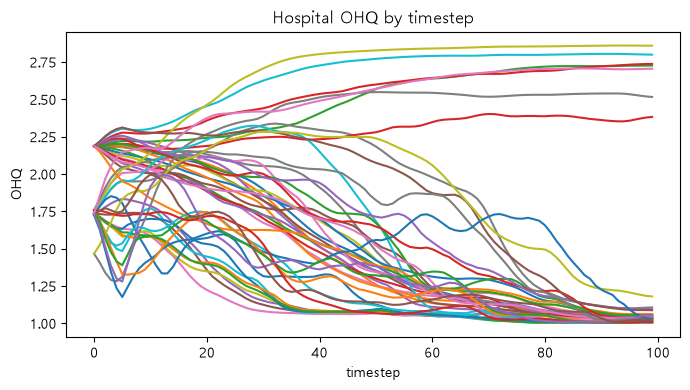

In [102]:
hospital_names = sim.df_Hospital_info['nm_hospital'].astype(str).to_numpy()
result = pd.DataFrame({
    'hospital': hospital_names,
    'total_new_patients': sim.arr_hospital_volume.sum(axis=0),
    'initial_OHQ': sim.achv_OHQ[0],
    'final_OHQ': sim.achv_OHQ[parameter_set.max_dt - 1],
}).sort_values('total_new_patients', ascending=False)

display(result.head(10))

plt.figure(figsize=(7, 4))

plt.plot(sim.achv_OHQ[:parameter_set.max_dt])

plt.title("Hospital OHQ by timestep")
plt.xlabel("timestep")
plt.ylabel("OHQ")

plt.tight_layout()
plt.show()

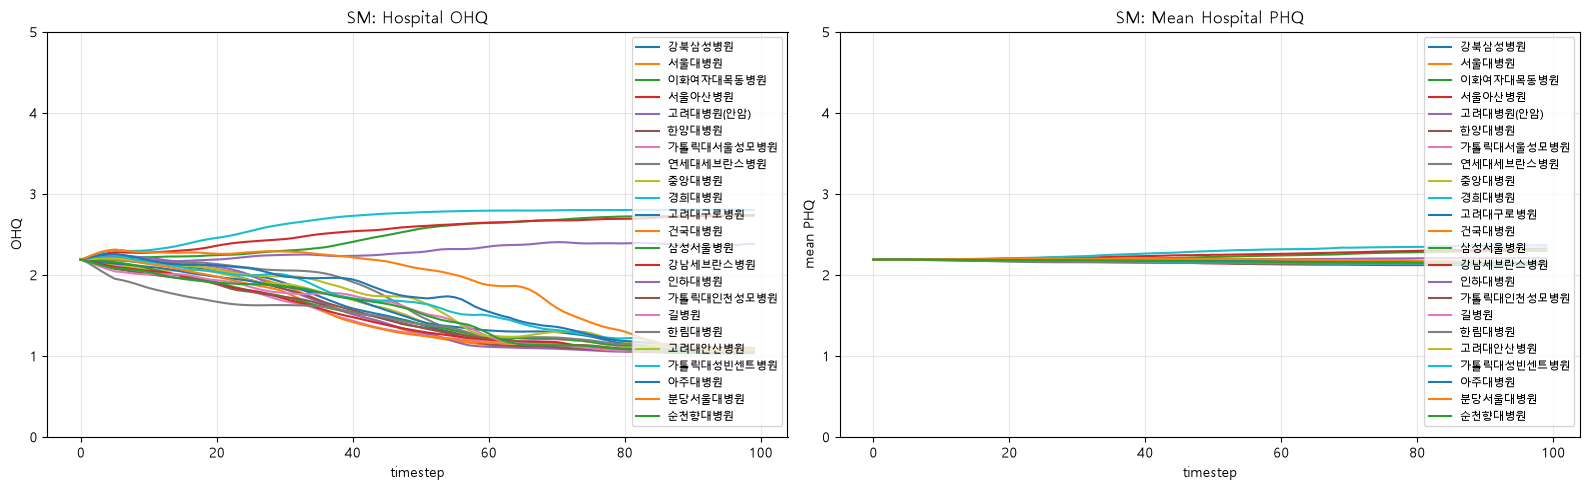

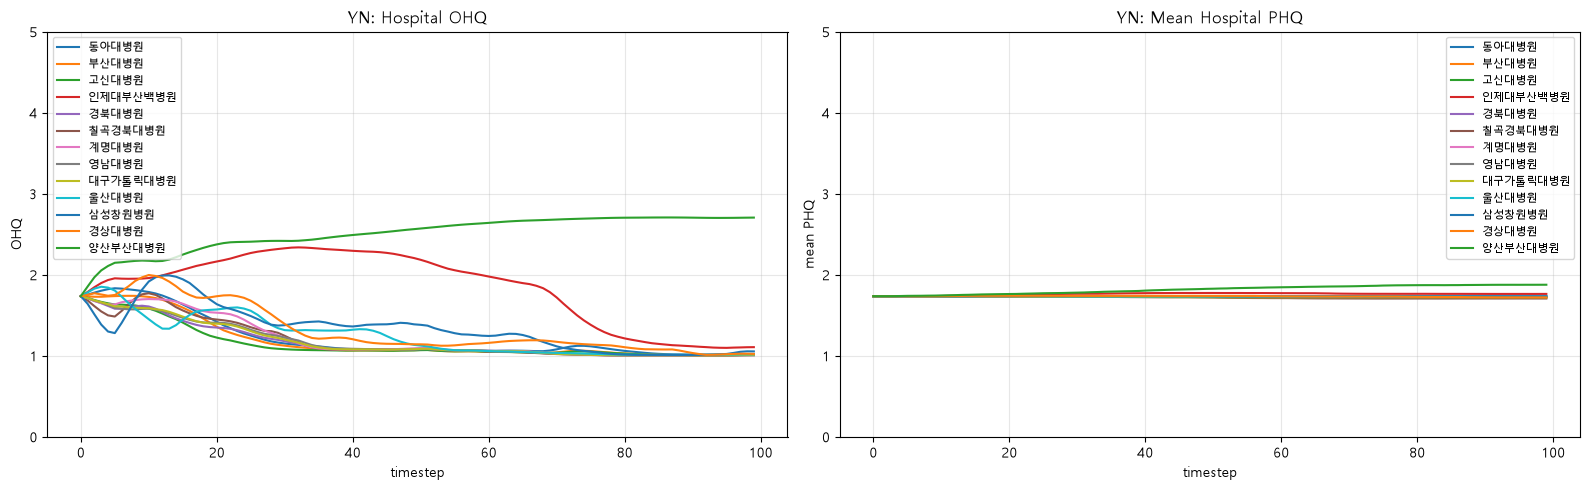

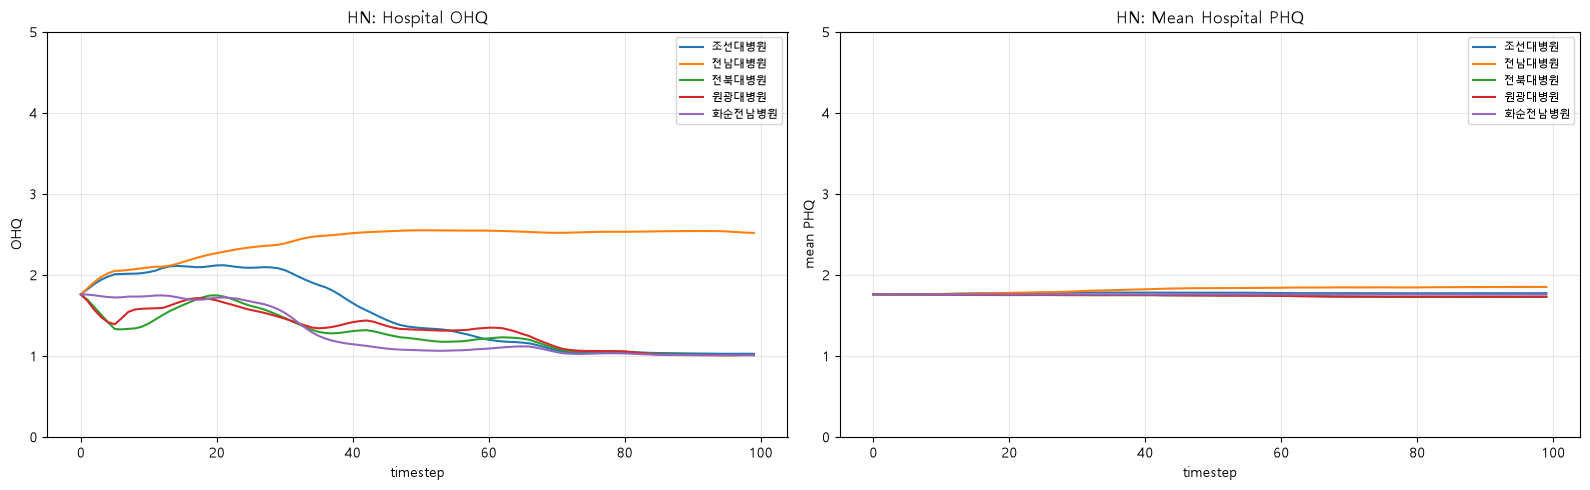

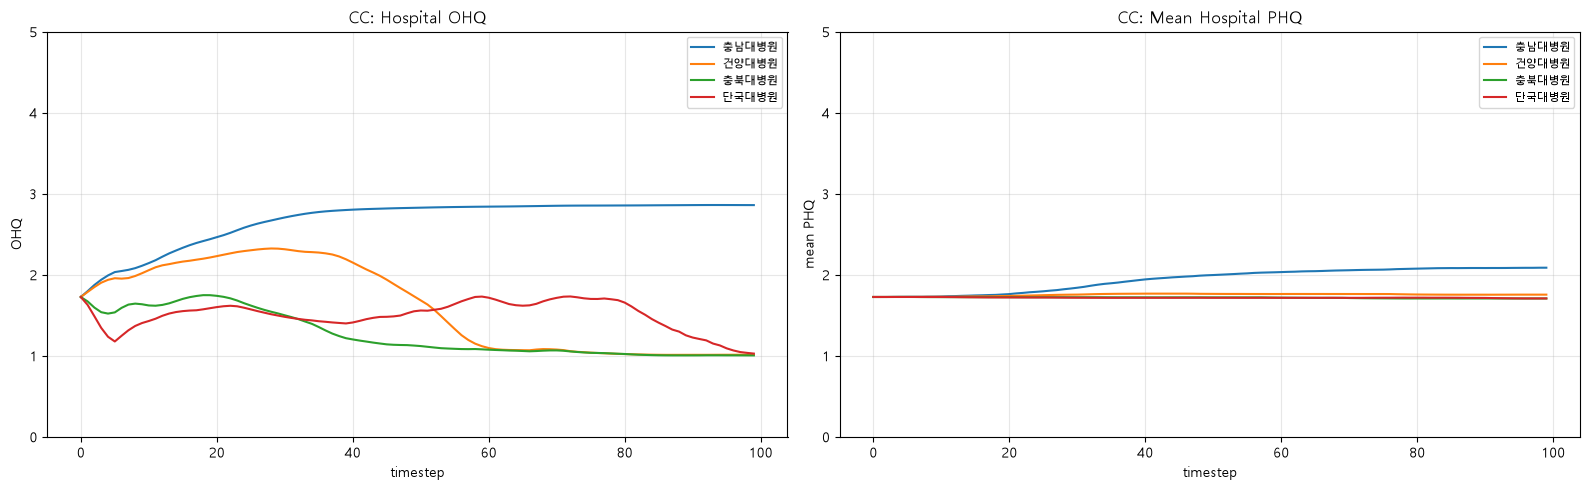

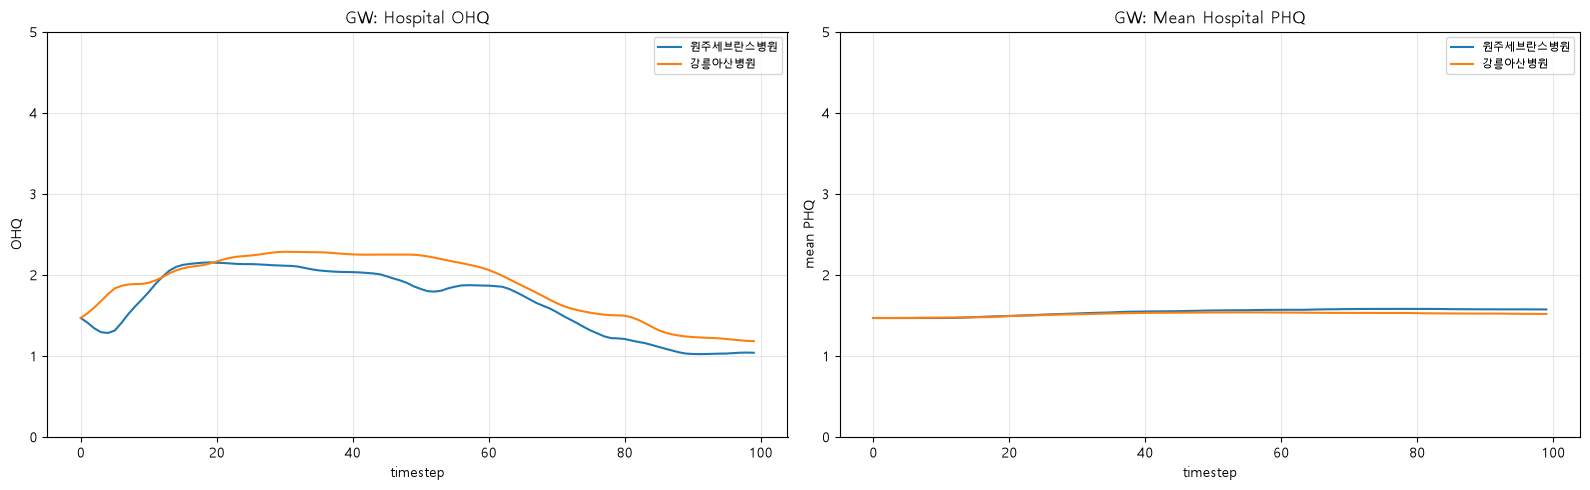

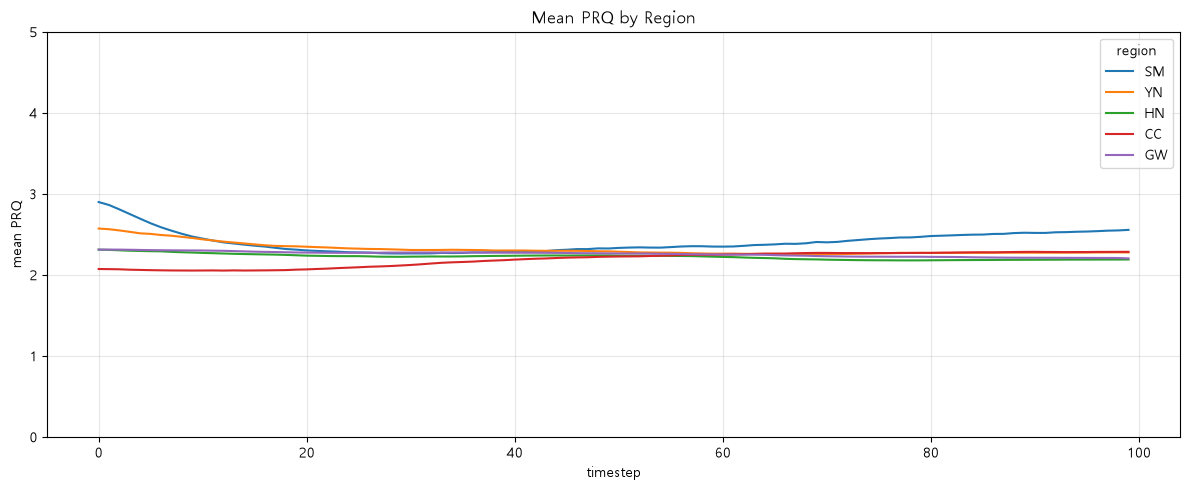

In [ ]:
hospital_regions = sim.df_Hospital_info['REGION'].to_numpy()
hospital_names = sim.df_Hospital_info['nm_hospital'].astype(str).to_numpy()
timesteps = np.arange(parameter_set.max_dt)
mean_PHQ_by_hospital = sim.achv_population_PHQ[:parameter_set.max_dt].mean(axis=1)

for region in pd.unique(hospital_regions):
    idx_hospitals = np.flatnonzero(hospital_regions == region)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

    for idx_hospital in idx_hospitals:
        label = hospital_names[idx_hospital]
        axes[0].plot(timesteps, sim.achv_OHQ[:parameter_set.max_dt, idx_hospital], label=label)
        axes[1].plot(timesteps, mean_PHQ_by_hospital[:, idx_hospital], label=label)

    axes[0].set(title=f'{region}: Hospital OHQ', xlabel='timestep', ylabel='OHQ', ylim=(0, 5))
    axes[1].set(title=f'{region}: Mean Hospital PHQ', xlabel='timestep', ylabel='mean PHQ', ylim=(0, 5))
    for ax in axes:
        ax.grid(alpha=0.3)
        ax.legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()

region_labels = list(parameter_set.dict_parameter_initial_PRQ.keys())
mean_PRQ_by_region = sim.achv_population_PRQ[:parameter_set.max_dt].mean(axis=1)
fig, ax = plt.subplots(figsize=(12, 5))
for idx_region, region in enumerate(region_labels):
    ax.plot(timesteps, mean_PRQ_by_region[:, idx_region], label=region)
ax.set(title='Mean PRQ by Region', xlabel='timestep', ylabel='mean PRQ', ylim=(0,5))
ax.grid(alpha=0.3)
ax.legend(title='region', loc='best')
plt.tight_layout()
plt.show()

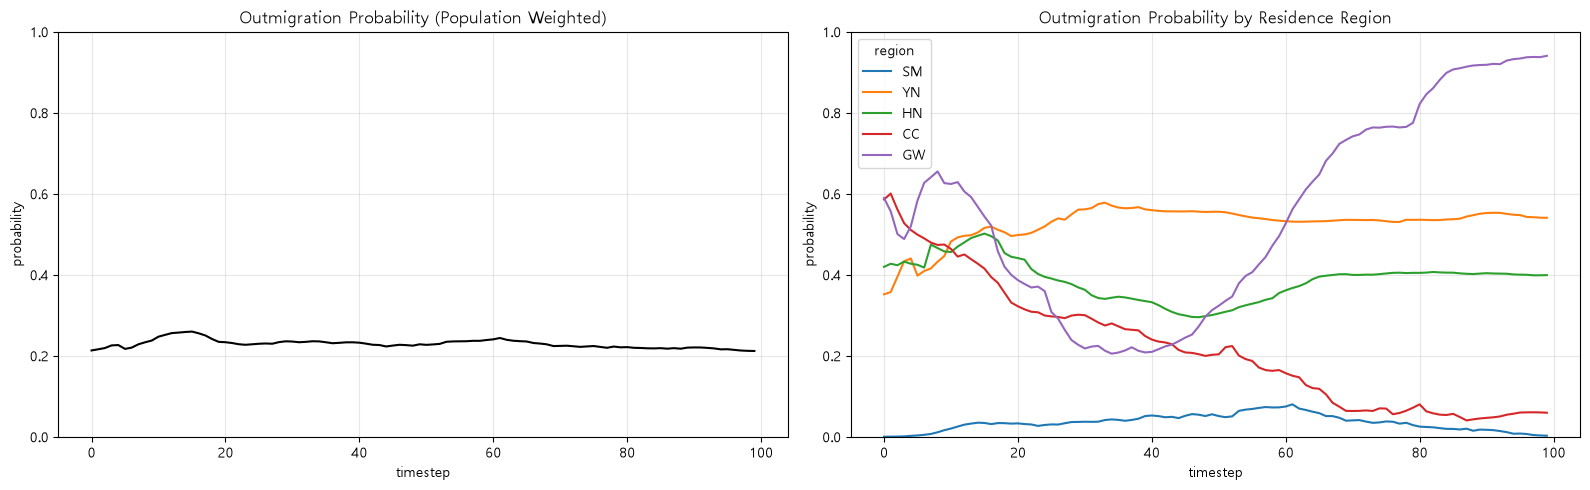

In [ ]:
region_labels = list(parameter_set.dict_parameter_initial_PRQ.keys())
hospital_regions = sim.df_Hospital_info['REGION'].to_numpy()
timesteps = np.arange(parameter_set.max_dt)
prob_outmigration = np.zeros((parameter_set.max_dt, len(region_labels)))
population_by_region = np.zeros(len(region_labels), dtype=int)

for idx_region, region in enumerate(region_labels):
    idx_people = sim.df_Person_info.loc[sim.df_Person_info['REGION'] == region, 'idx_person'].to_numpy()
    idx_out_of_region_hospitals = np.flatnonzero(hospital_regions != region)
    regional_mean_choice_prob = sim.achv_population_choice_prob[:parameter_set.max_dt, idx_people, :].mean(axis=1)
    prob_outmigration[:, idx_region] = regional_mean_choice_prob[:, idx_out_of_region_hospitals].sum(axis=1)
    population_by_region[idx_region] = len(idx_people)

population_weights = population_by_region / population_by_region.sum()
prob_outmigration_population_averaged = prob_outmigration @ population_weights

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
axes[0].plot(timesteps, prob_outmigration_population_averaged, color='black')
axes[0].set(title='Outmigration Probability (Population Weighted)', xlabel='timestep', ylabel='probability', ylim=(0, 1))

for idx_region, region in enumerate(region_labels):
    axes[1].plot(timesteps, prob_outmigration[:, idx_region], label=region)
axes[1].set(title='Outmigration Probability by Residence Region', xlabel='timestep', ylabel='probability', ylim=(0, 1))

for ax in axes:
    ax.grid(alpha=0.3)
axes[1].legend(title='region', loc='best')
plt.tight_layout()
plt.show()

In [101]:
OUTPUT_DIR = PROJECT_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

result.to_excel(OUTPUT_DIR / 'hospital_summary.xlsx', index=False)
np.save(OUTPUT_DIR / 'hospital_volume.npy', sim.arr_hospital_volume)
np.save(OUTPUT_DIR / 'hospital_OHQ.npy', sim.achv_OHQ)
print('저장 위치:', OUTPUT_DIR.resolve())

저장 위치: C:\Users\user\Desktop\대학원\기초연구실\ABM code\09171256_gym추가_son\outputs
